# Gauge sensitivity of rank-constrained broadcast

This KISS-style synthetic experiment isolates broadcast representation sensitivity. A fixed structured low-rank update $\Delta W_g=B_gA_g$ is represented through permutation, orthogonal, and controlled diagonal gauges. RBLA uses the resulting index prefix, while compact SP+ reorganizes the factors using two thin QR factorizations and an $R\times R$ core SVD. Dense SVD is used only as an offline optimal-error reference.

The experiment concerns only the broadcast representation. It does not claim that SP+ eliminates LoRA gauge freedom or repairs semantic mismatch introduced during aggregation. Controlled diagonal scaling is retained as a negative control: reciprocal column/row scaling leaves each indexed rank-one term, and therefore every prefix product, unchanged.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Structured synthetic LoRA update; no training checkpoint is required.
D_OUT = 128
D_IN = 96
R = 16
REQUESTED_RANKS = tuple(range(1, R + 1))
RANKS = tuple(r for r in REQUESTED_RANKS if r <= R)
GAUGE_TYPES = ("permutation", "orthogonal", "diagonal")
TRIALS_PER_TYPE = 100
SEED = 42
TARGET_SEED = 20260903
EPS = np.finfo(np.float64).eps
TOL = 1e-10
CONDITION_LIMIT = 10.0

if not RANKS or min(RANKS) >= R:
    raise ValueError("RANKS must contain at least one rank below R")

cwd = Path.cwd().resolve()
if cwd.name == "gauge_sensitivity":
    OUTPUT_DIR = cwd
else:
    OUTPUT_DIR = cwd / "rbla+" / "figures" / "gauge_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.45,
    "lines.markersize": 4.2,
    "grid.color": "0.75",
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.55,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

print(f"Output directory: {OUTPUT_DIR}")
print(f"Synthetic shape: {D_OUT} x {D_IN}; R={R}; ranks={RANKS}")
print(f"Gauge representations: {len(GAUGE_TYPES) * TRIALS_PER_TYPE} ({TRIALS_PER_TYPE}/type)")

Output directory: H:\paper-experiment-record\rbla+\figures\gauge_sensitivity
Synthetic shape: 128 x 96; R=16; ranks=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16)
Gauge representations: 300 (100/type)


In [2]:
def orthonormal_columns(rng: np.random.Generator, rows: int, columns: int) -> np.ndarray:
    """Return a deterministic thin orthonormal basis."""
    q, r = np.linalg.qr(rng.standard_normal((rows, columns)), mode="reduced")
    signs = np.where(np.diag(r) < 0.0, -1.0, 1.0)
    return q * signs[None, :]


def make_structured_factors(d_out: int, d_in: int, rank: int, seed: int):
    """Canonical factors with a fixed, non-uniform singular spectrum."""
    rng = np.random.default_rng(seed)
    u = orthonormal_columns(rng, d_out, rank)
    v = orthonormal_columns(rng, d_in, rank)
    singular_values = np.exp(-4.0 * np.arange(rank) / max(rank - 1, 1))
    sqrt_s = np.sqrt(singular_values)
    b_global = u * sqrt_s[None, :]
    a_global = sqrt_s[:, None] * v.T
    return b_global, a_global, singular_values


def make_gauge(gauge_type: str, rank: int, seed: int) -> np.ndarray:
    """Generate a reproducible, well-conditioned invertible gauge matrix."""
    rng = np.random.default_rng(seed)
    if gauge_type == "permutation":
        return np.eye(rank, dtype=np.float64)[:, rng.permutation(rank)]
    if gauge_type == "orthogonal":
        return orthonormal_columns(rng, rank, rank)
    if gauge_type == "diagonal":
        scales = np.exp(rng.uniform(np.log(0.5), np.log(2.0), size=rank))
        return np.diag(scales)
    raise ValueError(f"Unknown gauge type: {gauge_type}")


def apply_gauge(b_global: np.ndarray, a_global: np.ndarray, gauge: np.ndarray):
    """Apply (B G, G^{-1} A) without explicitly forming an inverse."""
    return b_global @ gauge, np.linalg.solve(gauge, a_global)


def compact_sp_plus(b_global: np.ndarray, a_global: np.ndarray):
    """Two thin QRs plus an R x R core SVD; never forms B @ A internally."""
    if b_global.ndim != 2 or a_global.ndim != 2:
        raise ValueError("LoRA factors must be matrices")
    if b_global.shape[1] != a_global.shape[0]:
        raise ValueError("Incompatible factor ranks")

    q_b, r_b = np.linalg.qr(b_global, mode="reduced")
    q_a, r_a = np.linalg.qr(a_global.T, mode="reduced")
    core = r_b @ r_a.T
    u_core, singular_values, vh_core = np.linalg.svd(core, full_matrices=False)
    sqrt_s = np.sqrt(np.maximum(singular_values, 0.0))
    b_plus = (q_b @ u_core) * sqrt_s[None, :]
    a_plus = sqrt_s[:, None] * (vh_core @ q_a.T)

    intermediate_shapes = {
        "q_b": q_b.shape, "r_b": r_b.shape,
        "q_a": q_a.shape, "r_a": r_a.shape,
        "core": core.shape, "u_core": u_core.shape,
        "vh_core": vh_core.shape,
        "b_plus": b_plus.shape, "a_plus": a_plus.shape,
    }
    dense_shape = (b_global.shape[0], a_global.shape[1])
    if any(shape == dense_shape for shape in intermediate_shapes.values()):
        raise AssertionError(f"Compact path created a dense-shaped intermediate: {dense_shape}")
    return b_plus, a_plus, singular_values, intermediate_shapes


def relative_frobenius_error(reference: np.ndarray, approximation: np.ndarray) -> float:
    numerator = np.linalg.norm(reference - approximation, ord="fro")
    denominator = np.linalg.norm(reference, ord="fro") + EPS
    return float(numerator / denominator)

In [3]:
b_global, a_global, designed_spectrum = make_structured_factors(
    D_OUT, D_IN, R, TARGET_SEED
)

# Dense construction and dense SVD are confined to this offline evaluator.
delta_w = b_global @ a_global
u_dense, s_dense, vh_dense = np.linalg.svd(delta_w, full_matrices=False)
dense_optimal_errors = {}
singular_value_gaps = {}
for r in RANKS:
    dense_rank_r = (u_dense[:, :r] * s_dense[:r][None, :]) @ vh_dense[:r, :]
    dense_optimal_errors[r] = relative_frobenius_error(delta_w, dense_rank_r)
    singular_value_gaps[r] = float(s_dense[r - 1] - s_dense[r])

records = []
for type_index, gauge_type in enumerate(GAUGE_TYPES):
    for trial in range(TRIALS_PER_TYPE):
        gauge_seed = SEED + 10_000 * type_index + trial
        gauge = make_gauge(gauge_type, R, gauge_seed)
        condition_number = float(np.linalg.cond(gauge, p=2))
        b_gauge, a_gauge = apply_gauge(b_global, a_global, gauge)

        # Dense products below are evaluation-only and are outside compact_sp_plus.
        delta_gauge = b_gauge @ a_gauge
        full_update_error = relative_frobenius_error(delta_w, delta_gauge)
        b_plus, a_plus, _, compact_shapes = compact_sp_plus(b_gauge, a_gauge)
        compact_path_ok = all(shape != delta_w.shape for shape in compact_shapes.values())

        for r in RANKS:
            rbla_rank_r = b_gauge[:, :r] @ a_gauge[:r, :]
            sp_rank_r = b_plus[:, :r] @ a_plus[:r, :]
            rbla_error = relative_frobenius_error(delta_w, rbla_rank_r)
            sp_error = relative_frobenius_error(delta_w, sp_rank_r)
            sp_dense_gap = abs(sp_error - dense_optimal_errors[r])

            common = {
                "dataset": "synthetic",
                "model": "structured_low_rank_update",
                "layer": "aggregate",
                "checkpoint": "N/A",
                "seed": SEED,
                "gauge_seed": gauge_seed,
                "trial": trial,
                "gauge_type": gauge_type,
                "condition_number": condition_number,
                "R": R,
                "r": r,
                "full_update_error": full_update_error,
                "dense_optimal_error": dense_optimal_errors[r],
                "sp_plus_dense_error_gap": sp_dense_gap,
                "singular_value_gap": singular_value_gaps[r],
                "compact_path_no_dense_intermediate": compact_path_ok,
                "d_out": D_OUT,
                "d_in": D_IN,
                "spectrum": "exp(-4*i/(R-1))",
            }
            records.append({**common, "method": "RBLA prefix", "broadcast_error": rbla_error})
            records.append({**common, "method": "SP+ (compact QR)", "broadcast_error": sp_error})

results = pd.DataFrame.from_records(records)
numeric_columns = [
    "condition_number", "full_update_error", "broadcast_error",
    "dense_optimal_error", "sp_plus_dense_error_gap", "singular_value_gap",
]
max_full_update_error = float(results["full_update_error"].max())
mean_full_update_error = float(results["full_update_error"].mean())
max_sp_dense_gap = float(results["sp_plus_dense_error_gap"].max())
max_condition_number = float(results["condition_number"].max())

rbla_nontrivial = results[
    (results["method"] == "RBLA prefix")
    & (results["gauge_type"].isin(["permutation", "orthogonal"]))
    & (results["r"] < R)
]
rbla_ranges = rbla_nontrivial.groupby("r")["broadcast_error"].agg(np.ptp)
diagonal_rbla = results[
    (results["method"] == "RBLA prefix")
    & (results["gauge_type"] == "diagonal")
]
diagonal_ranges = diagonal_rbla.groupby("r")["broadcast_error"].agg(np.ptp)

checks = {
    "all gauge matrices satisfy the condition-number limit": max_condition_number <= CONDITION_LIMIT,
    "full update is invariant under every gauge": max_full_update_error <= TOL,
    "SP+ error matches the dense optimum": max_sp_dense_gap <= TOL,
    "compact SP+ has no dense-shaped intermediate": bool(
        results["compact_path_no_dense_intermediate"].all()
    ),
    "all reported numeric values are finite": bool(
        np.isfinite(results[numeric_columns].to_numpy()).all()
    ),
    "all full-rank broadcast errors are near numerical precision": bool(
        results.loc[results["r"] == R, "broadcast_error"].max() <= TOL
    ),
    "non-diagonal gauges produce prefix sensitivity below full rank": bool(
        rbla_ranges.max() > 1e-3
    ),
    "diagonal scaling acts as a prefix-invariant negative control": bool(
        diagonal_ranges.max() <= TOL
    ),
}
all_checks_passed = all(checks.values())
results["numerical_checks_passed"] = all_checks_passed

csv_path = OUTPUT_DIR / "gauge_sensitivity_results.csv"
results.to_csv(csv_path, index=False, float_format="%.16e")
check_table = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
print(f"Saved {len(results):,} rows to {csv_path.name}")

,check,passed
0,all gauge matrices satisfy the condition-numbe...,True
1,full update is invariant under every gauge,True
2,SP+ error matches the dense optimum,True
3,compact SP+ has no dense-shaped intermediate,True
4,all reported numeric values are finite,True
5,all full-rank broadcast errors are near numeri...,True
6,non-diagonal gauges produce prefix sensitivity...,True
7,diagonal scaling acts as a prefix-invariant ne...,True


Saved 9,600 rows to gauge_sensitivity_results.csv


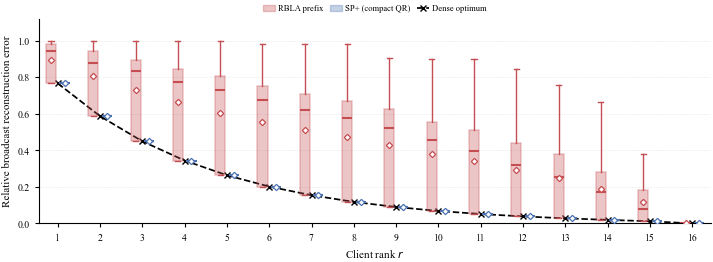

Saved vector figure to gauge_sensitivity.pdf


In [4]:
colors = {
    "RBLA prefix": "#C44E52",
    "SP+ (compact QR)": "#4C72B0",
}
rank_centers = np.arange(1, len(RANKS) + 1, dtype=float)
offsets = {"RBLA prefix": -0.16, "SP+ (compact QR)": 0.16}

fig, ax = plt.subplots(figsize=(7.16, 2.65))
dense_values = [dense_optimal_errors[r] for r in RANKS]
ax.plot(
    rank_centers, dense_values,
    color="black", linestyle="--", marker="x", linewidth=1.25,
    markersize=4.5, zorder=1,
)

for method in ("RBLA prefix", "SP+ (compact QR)"):
    distributions = [
        results.loc[
            (results["method"] == method) & (results["r"] == r),
            "broadcast_error",
        ].to_numpy()
        for r in RANKS
    ]
    positions = rank_centers + offsets[method]
    color = colors[method]
    ax.boxplot(
        distributions,
        positions=positions,
        widths=0.24,
        manage_ticks=False,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.32, "linewidth": 1.1},
        whiskerprops={"color": color, "linewidth": 1.0},
        capprops={"color": color, "linewidth": 1.0},
        medianprops={"color": color, "linewidth": 1.5},
        meanprops={
            "marker": "D", "markerfacecolor": "white", "markeredgecolor": color,
            "markeredgewidth": 0.9, "markersize": 3.2,
        },
        zorder=3,
    )

ax.set_xlabel(r"Client rank $r$")
ax.set_ylabel("Relative broadcast reconstruction error")
ax.set_xticks(rank_centers)
ax.set_xticklabels([str(r) for r in RANKS])
ax.set_xlim(0.55, len(RANKS) + 0.45)
max_error = float(results["broadcast_error"].max())
ax.set_ylim(0.0, max_error * 1.12)
ax.grid(True, axis="y", which="major")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", width=0.8, length=3)

legend_handles = [
    Patch(facecolor=colors["RBLA prefix"], edgecolor=colors["RBLA prefix"], alpha=0.32,
          label="RBLA prefix"),
    Patch(facecolor=colors["SP+ (compact QR)"], edgecolor=colors["SP+ (compact QR)"], alpha=0.32,
          label="SP+ (compact QR)"),
    Line2D([0], [0], color="black", linestyle="--", marker="x", linewidth=1.25,
           markersize=4.5, label="Dense optimum"),
]
ax.legend(
    handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 1.01),
    ncol=3, fontsize=6.2, handlelength=1.4, handletextpad=0.35,
    columnspacing=0.75, borderaxespad=0.0,
)
fig.tight_layout(pad=0.3)

pdf_path = OUTPUT_DIR / "gauge_sensitivity.pdf"
fig.savefig(pdf_path)
plt.show()
print(f"Saved vector figure to {pdf_path.name}")

In [5]:
summary_stats = (
    results.groupby(["r", "method"])["broadcast_error"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
display(summary_stats)

print("Gauge-sensitivity experiment summary")
print("  data source: structured synthetic factors (checkpoint: N/A)")
print(f"  shape: {D_OUT} x {D_IN}; R={R}; ranks={RANKS}")
print(f"  gauge trials: {len(GAUGE_TYPES) * TRIALS_PER_TYPE} total "
      f"({TRIALS_PER_TYPE} each for {', '.join(GAUGE_TYPES)})")
print(f"  condition-number range: {results['condition_number'].min():.6f} "
      f"to {results['condition_number'].max():.6f}")
print(f"  full-update invariance error: mean={mean_full_update_error:.3e}, "
      f"max={max_full_update_error:.3e}")
print(f"  maximum SP+ versus dense-optimum error difference: {max_sp_dense_gap:.3e}")
print(f"  all numerical checks passed: {all_checks_passed}")
print("  interpretation: equivalent gauges preserve the complete update; non-diagonal")
print("  gauges alter RBLA index prefixes, while compact SP+ remains at the optimal")
print("  rank-constrained error. This does not address aggregation-stage mismatch or")
print("  imply that SP+ eliminates LoRA gauge freedom.")

,r,method,mean,std,min,max
0,1,RBLA prefix,8.945674e-01,9.939945e-02,7.658752e-01,9.999307e-01
1,1,SP+ (compact QR),7.658752e-01,2.942282e-17,7.658752e-01,7.658752e-01
2,2,RBLA prefix,8.060614e-01,1.652779e-01,5.865362e-01,9.998124e-01
3,2,SP+ (compact QR),5.865362e-01,5.255476e-17,5.865362e-01,5.865362e-01
4,3,RBLA prefix,7.290053e-01,2.106082e-01,4.491541e-01,9.994688e-01
5,3,SP+ (compact QR),4.491541e-01,6.005908e-17,4.491541e-01,4.491541e-01
6,4,RBLA prefix,6.627792e-01,2.417468e-01,3.439016e-01,9.987506e-01
7,4,SP+ (compact QR),3.439016e-01,3.812011e-17,3.439016e-01,3.439016e-01
8,5,RBLA prefix,6.045556e-01,2.600638e-01,2.632495e-01,9.977508e-01
9,5,SP+ (compact QR),2.632495e-01,1.471141e-17,2.632495e-01,2.632495e-01


Gauge-sensitivity experiment summary
  data source: structured synthetic factors (checkpoint: N/A)
  shape: 128 x 96; R=16; ranks=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16)
  gauge trials: 300 total (100 each for permutation, orthogonal, diagonal)
  condition-number range: 1.000000 to 3.989798
  full-update invariance error: mean=2.304e-16, max=4.642e-16
  maximum SP+ versus dense-optimum error difference: 1.733e-15
  all numerical checks passed: True
  interpretation: equivalent gauges preserve the complete update; non-diagonal
  gauges alter RBLA index prefixes, while compact SP+ remains at the optimal
  rank-constrained error. This does not address aggregation-stage mismatch or
  imply that SP+ eliminates LoRA gauge freedom.
